# Modelo 3 — EfficientNetB0
Clasificación de tumores cerebrales con EfficientNetB0 (transfer learning + fine-tuning).

Proyecto de Cátedra IAR105 · Sistema CAD para detección de tumores cerebrales en MRI

## 1. Preparación del entorno

In [ ]:
# Verificar que la GPU esté activa
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("TensorFlow:", tf.__version__)
print("GPU activa" if gpus else "SIN GPU")

TensorFlow: 2.20.0
GPU activa


In [2]:
# Montar Google Drive (contiene el dataset comprimido)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Copiar el dataset desde Drive al disco local de Colab y descomprimir
import shutil, os

ZIP_EN_DRIVE = "/content/drive/MyDrive/dataset.zip"

shutil.copy(ZIP_EN_DRIVE, "/content/dataset.zip")
!unzip -q /content/dataset.zip -d /content/
print("Dataset descomprimido.")

Dataset descomprimido.


In [4]:
# Localizar las carpetas Training y Testing
import os
for raiz, carpetas, archivos in os.walk("/content"):
    if "Training" in carpetas and "Testing" in carpetas:
        print("Dataset encontrado en:", raiz)
        break

Dataset encontrado en: /content/dataset


## 2. Análisis Exploratorio de Datos (EDA)

Se caracteriza el dataset antes de definir el preprocesamiento: distribución de clases,
propiedades de las imágenes (tamaño, canales, rango de píxeles) y ejemplos visuales.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

BASE_DIR = "/content/dataset"
TRAIN_DIR = f"{BASE_DIR}/Training"
TEST_DIR  = f"{BASE_DIR}/Testing"
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

In [6]:
# Conteo de imágenes por clase
conteos = []
for split, carpeta in [("Training", TRAIN_DIR), ("Testing", TEST_DIR)]:
    for clase in CLASSES:
        n = len(os.listdir(f"{carpeta}/{clase}"))
        conteos.append({"split": split, "clase": clase, "cantidad": n})

tabla = pd.DataFrame(conteos).pivot(index="clase", columns="split", values="cantidad")
tabla["TOTAL"] = tabla["Training"] + tabla["Testing"]
print(tabla)
print("\nTotal de imágenes:", tabla["TOTAL"].sum())

split       Testing  Training  TOTAL
clase                               
glioma          755      3018   3773
meningioma      546      2183   2729
notumor         487      1945   2432
pituitary       626      2504   3130

Total de imágenes: 12064


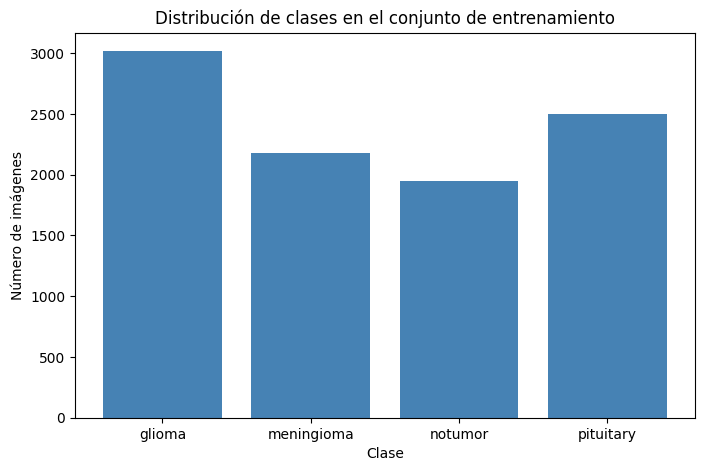

Clase mayoritaria: glioma (3018)
Clase minoritaria: notumor (1945)
Ratio de desbalance: 1.55x


In [7]:
# Distribución de clases (entrenamiento) y ratio de desbalance
train_counts = tabla["Training"]
plt.figure(figsize=(8, 5))
plt.bar(train_counts.index, train_counts.values, color="steelblue")
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.ylabel("Número de imágenes")
plt.xlabel("Clase")
plt.show()

ratio = train_counts.max() / train_counts.min()
print(f"Clase mayoritaria: {train_counts.idxmax()} ({train_counts.max()})")
print(f"Clase minoritaria: {train_counts.idxmin()} ({train_counts.min()})")
print(f"Ratio de desbalance: {ratio:.2f}x")

In [8]:
# Propiedades de una imagen de ejemplo
ejemplo = f"{TRAIN_DIR}/glioma/" + os.listdir(f"{TRAIN_DIR}/glioma")[0]
img = cv2.imread(ejemplo, cv2.IMREAD_UNCHANGED)
print("dtype:", img.dtype)
print("shape:", img.shape)
print("min:", img.min(), "| max:", img.max())

dtype: uint8
shape: (512, 512)
min: 0 | max: 250


In [9]:
# Escaneo de una muestra: tamaños y canales
import random
random.seed(42)

formas, identicos, total = [], 0, 0
for clase in CLASSES:
    archivos = os.listdir(f"{TRAIN_DIR}/{clase}")
    for nombre in random.sample(archivos, min(150, len(archivos))):
        im = cv2.imread(f"{TRAIN_DIR}/{clase}/{nombre}", cv2.IMREAD_UNCHANGED)
        formas.append(im.shape)
        total += 1
        if im.ndim == 3 and im.shape[2] == 3:
            if np.array_equal(im[:, :, 0], im[:, :, 1]) and np.array_equal(im[:, :, 1], im[:, :, 2]):
                identicos += 1

print("Tamaños más frecuentes:")
print(pd.Series(formas).value_counts().head(8))
print(f"\nRevisadas: {total} | con 3 canales idénticos (gris): {identicos}")

Tamaños más frecuentes:
(224, 224, 3)    206
(512, 512, 3)    150
(512, 512)       125
(225, 225, 3)     13
(236, 236, 3)     10
(222, 227, 3)      4
(217, 232, 3)      3
(221, 228, 3)      3
Name: count, dtype: int64

Revisadas: 600 | con 3 canales idénticos (gris): 465


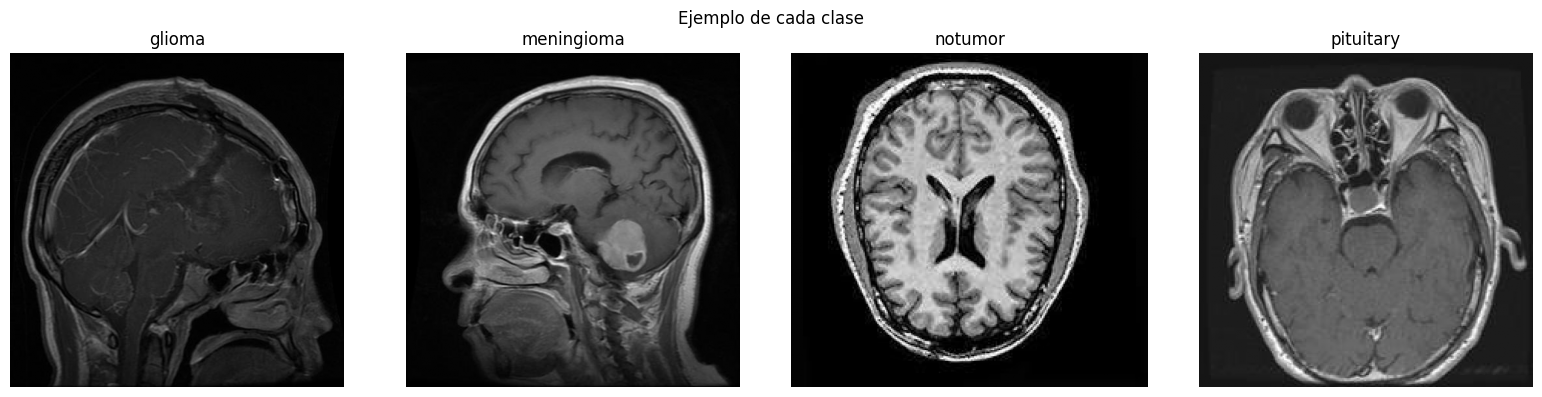

In [10]:
# Un ejemplo visual de cada clase
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, clase in zip(axes, CLASSES):
    archivo = f"{TRAIN_DIR}/{clase}/" + os.listdir(f"{TRAIN_DIR}/{clase}")[0]
    im = cv2.imread(archivo, cv2.IMREAD_GRAYSCALE)
    ax.imshow(im, cmap="gray")
    ax.set_title(clase)
    ax.axis("off")
plt.suptitle("Ejemplo de cada clase")
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

Decisiones tomadas a partir del EDA:
- Redimensionamiento a **224×224** (unifica las resoluciones heterogéneas).
- **3 canales (RGB)** y normalización 0–1 (embebida dentro del modelo).
- **Aumento de datos** realista, solo en entrenamiento.
- **15 %** del entrenamiento reservado para validación.
- **Ponderación de clases** para compensar el desbalance.

In [11]:
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, labels="inferred", label_mode="categorical",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    validation_split=0.15, subset="training", seed=SEED, shuffle=True)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, labels="inferred", label_mode="categorical",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    validation_split=0.15, subset="validation", seed=SEED, shuffle=True)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR, labels="inferred", label_mode="categorical",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_ds.class_names
print("Clases:", class_names)

# Cache en DISCO (no en RAM) + prefetch
train_ds = train_ds.cache("/content/cache_train").prefetch(AUTOTUNE)
val_ds   = val_ds.cache("/content/cache_val").prefetch(AUTOTUNE)
test_ds  = test_ds.cache("/content/cache_test").prefetch(AUTOTUNE)

Found 9650 files belonging to 4 classes.
Using 8203 files for training.
Found 9650 files belonging to 4 classes.
Using 1447 files for validation.
Found 2414 files belonging to 4 classes.
Clases: ['glioma', 'meningioma', 'notumor', 'pituitary']


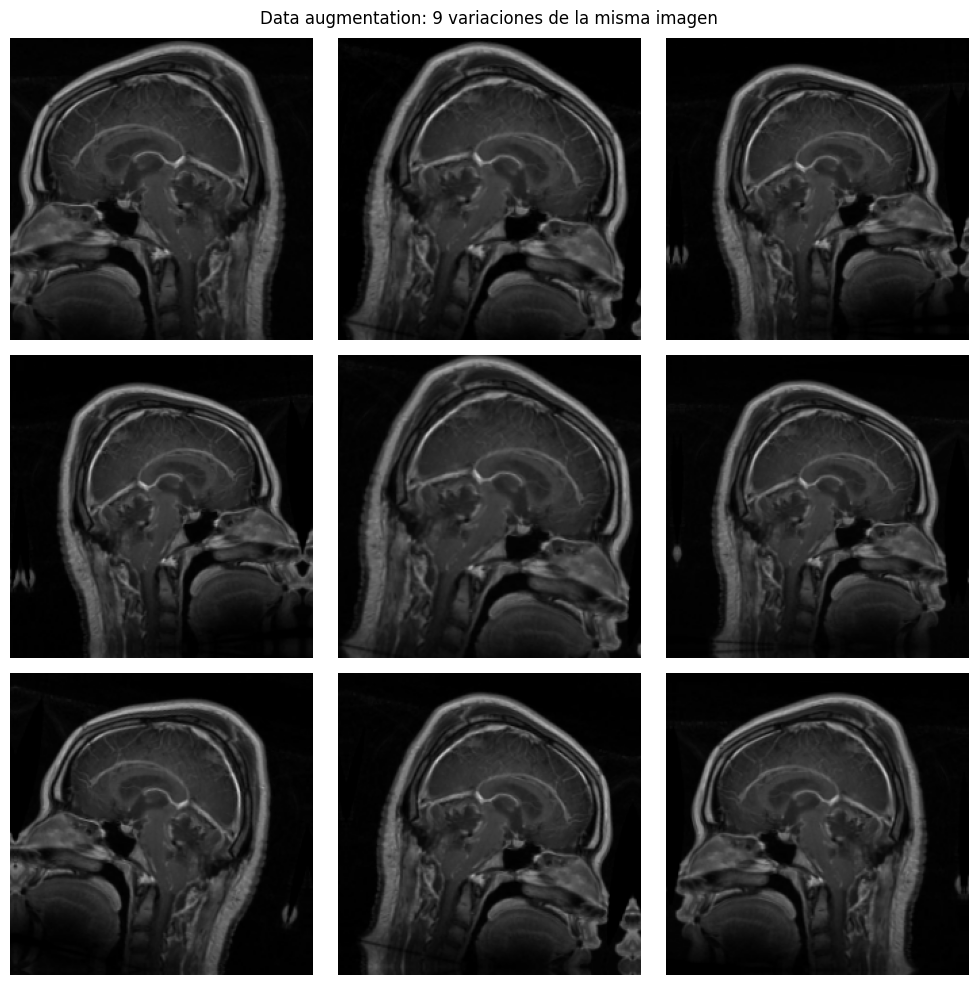

In [12]:
# Data augmentation
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.04),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomContrast(0.1),
], name="data_augmentation")

# Vista previa del augmentation
for imagenes, _ in train_ds.take(1):
    ejemplo_img = imagenes[0]
    break
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    aug = data_augmentation(tf.expand_dims(ejemplo_img, 0), training=True)
    plt.imshow(aug[0].numpy().astype("uint8"))
    plt.axis("off")
plt.suptitle("Data augmentation: 9 variaciones de la misma imagen")
plt.tight_layout()
plt.show()

In [13]:
# Ponderación de clases (class_weight balanceado)
counts = np.array([len(os.listdir(f"{TRAIN_DIR}/{c}")) for c in class_names])
class_weight = {i: float(counts.sum() / (len(class_names) * counts[i]))
                for i in range(len(class_names))}
for i, c in enumerate(class_names):
    print(f"{c:12s}: {counts[i]:4d} imágenes -> peso {class_weight[i]:.3f}")

glioma      : 3018 imágenes -> peso 0.799
meningioma  : 2183 imágenes -> peso 1.105
notumor     : 1945 imágenes -> peso 1.240
pituitary   : 2504 imágenes -> peso 0.963


## 4. Modelo: EfficientNetB0 (Transfer Learning)

In [14]:
# Construcción con base preentrenada en ImageNet (congelada)
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = keras.applications.efficientnet.preprocess_input(x)                     # preprocesamiento propio del modelo

base = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(224, 224, 3))
base.trainable = False                    # Fase 1: base congelada

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="efficientnetb0_transfer")
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
# Fase 1: entrenar solo la cabeza (base congelada)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/mejor_modelo_effnet.keras",
                                    monitor="val_loss", save_best_only=True),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=20,
                    class_weight=class_weight, callbacks=callbacks)

Epoch 1/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 69s 203ms/step - accuracy: 0.7214 - loss: 0.7306 - val_accuracy: 0.7934 - val_loss: 0.5659
Epoch 2/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 29s 112ms/step - accuracy: 0.8074 - loss: 0.5139 - val_accuracy: 0.8279 - val_loss: 0.4728
Epoch 3/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 29s 113ms/step - accuracy: 0.8284 - loss: 0.4653 - val_accuracy: 0.8341 - val_loss: 0.4540
Epoch 4/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.8455 - loss: 0.4267 - val_accuracy: 0.8438 - val_loss: 0.4232
Epoch 5/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 28s 108ms/step - accuracy: 0.8508 - loss: 0.4081 - val_accuracy: 0.8563 - val_loss: 0.3999
Epoch 6/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 28s 108ms/step - accuracy: 0.8533 - loss: 0.3998 - val_accuracy: 0.8659 - val_loss: 0.3826
Epoch 7/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.8598 - loss: 0.3815 - val_accuracy: 0.8625 - val_loss: 0.3772
Epoch 8/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 28s 108ms/step - accuracy: 0.8602 - loss: 0

### 4.1 Fine-tuning

Se descongela la base y se reentrena con un *learning rate* muy bajo (1e-5) para
adaptar las características de ImageNet al dominio de las imágenes MRI.

In [16]:
base.trainable = True   # descongelar toda la base

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
              loss="categorical_crossentropy", metrics=["accuracy"])

callbacks_ft = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/mejor_modelo_effnet_ft.keras",
                                    monitor="val_loss", save_best_only=True),
]

history_ft = model.fit(train_ds, validation_data=val_ds, epochs=15,
                       class_weight=class_weight, callbacks=callbacks_ft)

# Historial combinado (fase congelada + fine-tuning) para las curvas
H = {k: history.history[k] + history_ft.history[k] for k in history.history}

Epoch 1/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 147s 405ms/step - accuracy: 0.6707 - loss: 0.9310 - val_accuracy: 0.7975 - val_loss: 0.5073
Epoch 2/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 99s 387ms/step - accuracy: 0.7946 - loss: 0.5720 - val_accuracy: 0.8044 - val_loss: 0.5107
Epoch 3/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 144s 395ms/step - accuracy: 0.8404 - loss: 0.4479 - val_accuracy: 0.8424 - val_loss: 0.4515
Epoch 4/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 142s 397ms/step - accuracy: 0.8665 - loss: 0.3661 - val_accuracy: 0.8639 - val_loss: 0.3933
Epoch 5/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 102s 395ms/step - accuracy: 0.8855 - loss: 0.3218 - val_accuracy: 0.8770 - val_loss: 0.3616
Epoch 6/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 101s 394ms/step - accuracy: 0.9022 - loss: 0.2730 - val_accuracy: 0.8901 - val_loss: 0.3276
Epoch 7/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 142s 393ms/step - accuracy: 0.9120 - loss: 0.2383 - val_accuracy: 0.8977 - val_loss: 0.2995
Epoch 8/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 101s 392ms/step - accuracy: 0.9220 - 

## 5. Evaluación y métricas

Se evalúa el modelo sobre el conjunto de **prueba** (no visto en el entrenamiento) con
las métricas requeridas: accuracy, precision, recall, F1-score y matriz de confusión.

In [17]:
# Accuracy y loss en el conjunto de prueba
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 20s 269ms/step - accuracy: 0.8977 - loss: 0.3099

Test accuracy: 0.8977  |  Test loss: 0.3099


In [18]:
# Reporte de clasificación: precision, recall y F1 por clase
from sklearn.metrics import classification_report, confusion_matrix

y_true = np.concatenate([y.numpy() for x, y in test_ds])
y_true = np.argmax(y_true, axis=1)
y_pred = np.argmax(model.predict(test_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step
              precision    recall  f1-score   support

      glioma     0.9354    0.8437    0.8872       755
  meningioma     0.8571    0.7802    0.8169       546
     notumor     0.9428    0.9815    0.9618       487
   pituitary     0.8587    1.0000    0.9240       626

    accuracy                         0.8977      2414
   macro avg     0.8985    0.9014    0.8975      2414
weighted avg     0.8993    0.8977    0.8959      2414



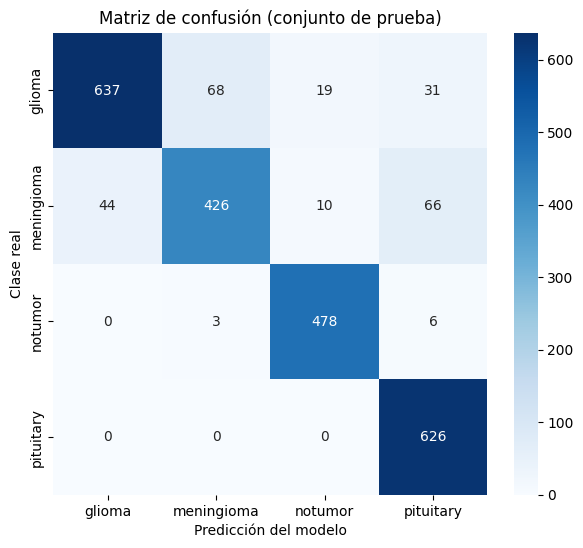

In [19]:
# Matriz de confusión
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción del modelo")
plt.ylabel("Clase real")
plt.title("Matriz de confusión (conjunto de prueba)")
plt.show()

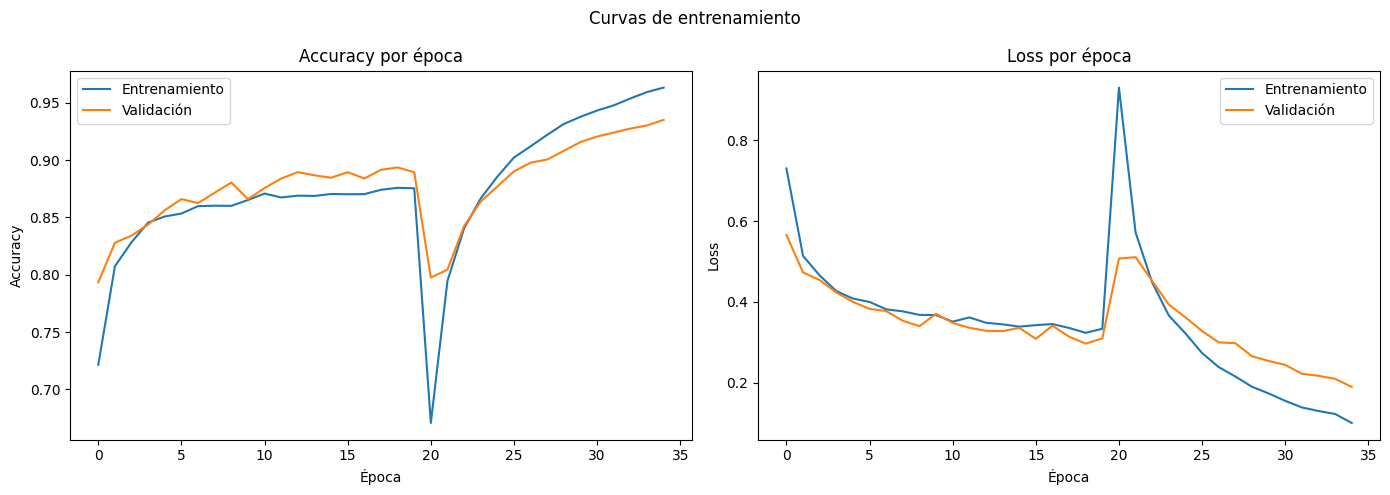

In [20]:
# Curvas de entrenamiento
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.plot(H["accuracy"], label="Entrenamiento")
a1.plot(H["val_accuracy"], label="Validación")
a1.set_title("Accuracy por época")
a1.set_xlabel("Época")
a1.set_ylabel("Accuracy")
a1.legend()
a2.plot(H["loss"], label="Entrenamiento")
a2.plot(H["val_loss"], label="Validación")
a2.set_title("Loss por época")
a2.set_xlabel("Época")
a2.set_ylabel("Loss")
a2.legend()
plt.suptitle("Curvas de entrenamiento")
plt.tight_layout()
plt.show()